In [ ]:
import marimo as mo

# TL:DR

- Agreement is strongest on grammar and tone, and still high on fluency.
- Per-criterion judging helps length, but grounding agreement stays near zero in both modes.
- The judge is generally more lenient than the human on Baseline, Exp 1, Exp 2, and Exp 3.

### a. What are the practical trade-offs between human evaluation and LLM-as-a-judge (think: cost, scale, consistency, accuracy)?
In this repo, the LLM judge clearly wins on cost, scale, and consistency: once the rubric and prompt are fixed, it can score the full experiment table reproducibly and much faster than a human review pass. The agreement table shows that this works well for style-oriented criteria such as grammar (98.7% agreement), tone (97-99%), and fluency (91-92%).

The trade-off is accuracy on harder criteria. Length agreement is only moderate, though it improves when judging one criterion at a time. Grounding is the main failure mode: agreement is near zero in both judge modes, which means the model is not reliably catching unsupported claims the same way the human scorer does. The experiment-level pass rates also show systematic leniency: for Baseline through Exp 3, judge pass rates are consistently above the human pass rates.
### b. Which approach would you recommend for a production system that generates thousands of descriptions daily?
I would use a hybrid workflow: human scoring for rubric design and periodic calibration, then LLM-as-a-judge for large-scale routine monitoring. In this dataset, that is a good fit because the automated judge is strong on grammar, tone, and fluency, which are exactly the dimensions that become expensive to review at scale.

I would not rely on the judge alone for grounding-sensitive decisions. The current results show that grounding still needs human calibration or stronger task-specific checks before it should drive final shipping decisions.

# Task 6 — Run and Analyze the Judge

Task 5 defined the judge. This notebook runs it across the full Task 4 experiment table,
compares all-at-once versus per-criterion judging, and measures agreement against the
human-labeled subset.

In [ ]:
from _bootstrap import bootstrap_notebook

bootstrap_notebook()

import mlflow
import pandas as pd

from src.artifacts import load_csv_artifact
from src.config import (
    PROMPT_JUDGE_ALL,
    PROMPT_JUDGE_SINGLE,
    get_force_rerun,
    get_judge_config,
    get_judge_max_concurrency,
    prompt_path,
)
from src.judge_runtime import (
    build_all_criteria_prompt,
    create_all_at_once_judge,
    create_single_judges,
)
from src.paths import (
    TASK_04_EXPERIMENTS_XLSX_PATH,
    TASK_06_JUDGED_EXPERIMENTS_CSV_PATH,
)
from src.runtime import load_project_env, read_text, setup_mlflow
from src.rubric import JUDGED_COLS, JUDGED_CRITERIA, compute_final_score
from src.task4_export import load_task4_experiments_table
from src.utils import format_judge_input, run_sync_batch

load_project_env()
setup_mlflow("judge_runs")

PosixPath('/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/w2-ai-product/outputs/experiments.db')

In [ ]:
FORCE_RERUN = get_force_rerun()
judge_config = get_judge_config()
JUDGE_MODEL = judge_config.model
JUDGE_MAX_CONCURRENCY = get_judge_max_concurrency()
all_prompt_template = read_text(prompt_path(PROMPT_JUDGE_ALL))
single_prompt_template = read_text(prompt_path(PROMPT_JUDGE_SINGLE))
JUDGE_PROMPT = build_all_criteria_prompt(all_prompt_template)
print(f"Judge model: {JUDGE_MODEL}")
print(f"Judge max concurrency: {JUDGE_MAX_CONCURRENCY}")
if FORCE_RERUN:
    print("FORCE_RERUN=1 — ignoring existing Task 6 artifact.")

Judge model: nebius/google/gemma-2-9b-it-fast
Judge max concurrency: 6


In [ ]:
df_experiments = load_task4_experiments_table(TASK_04_EXPERIMENTS_XLSX_PATH)
print(
    f"Loaded {len(df_experiments)} Task 4 experiment rows from {TASK_04_EXPERIMENTS_XLSX_PATH}"
)

Loaded 250 Task 4 experiment rows from /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/w2-ai-product/outputs/task_04_experiments.xlsx


In [ ]:
required_columns = [
    "experiment_label",
    "generated_description",
    "judge_status",
    "judge_final_score",
    "single_judge_status",
    "single_final_score",
    *[f"judge_{criterion_name}" for criterion_name in JUDGED_COLS],
    *[f"single_{criterion_name}" for criterion_name in JUDGED_COLS],
]
existing_task6_results = None
if not FORCE_RERUN:
    existing_task6_results = load_csv_artifact(
        TASK_06_JUDGED_EXPERIMENTS_CSV_PATH,
        required_columns=required_columns,
    )

if existing_task6_results is not None:
    print(f"Source: loaded existing artifact {TASK_06_JUDGED_EXPERIMENTS_CSV_PATH}")
else:
    print(
        f"Source: artifact missing or invalid, live judge runs may execute -> {TASK_06_JUDGED_EXPERIMENTS_CSV_PATH}"
    )

Source: loaded existing artifact /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/w2-ai-product/outputs/task_06_judged_experiments.csv


In [ ]:
run_judge = create_all_at_once_judge(
    model=JUDGE_MODEL,
    prompt=JUDGE_PROMPT,
    format_judge_input=format_judge_input,
)

## Task 6.1 — All-at-Once Judge Run

Run the structured judge across the full Task 4 experiment table: baseline plus all
improved experiment outputs.

In [ ]:
if existing_task6_results is not None:
    print(
        f"Skipping live all-at-once judge run; using {TASK_06_JUDGED_EXPERIMENTS_CSV_PATH}"
    )
    df_all_at_once = existing_task6_results.copy()
else:
    task6_all_criteria_names = list(JUDGED_COLS)
    task6_all_input_rows = df_experiments.to_dict("records")

    def _judge_all_sync(task6_all_row_data: dict[str, object]) -> dict[str, object]:
        try:
            task6_all_result = run_judge(
                task6_all_row_data,
                str(task6_all_row_data["generated_description"]),
            )
            task6_all_ratings = task6_all_result.to_ratings()
            task6_all_combined_ratings = {
                **task6_all_ratings,
                "latency": str(task6_all_row_data.get("latency", ""))
                .strip()
                .lower(),
                "cost": str(task6_all_row_data.get("cost", "")).strip().lower(),
            }
            task6_all_final_score = compute_final_score(task6_all_combined_ratings)
            return {
                **{
                    f"judge_{key}": value
                    for key, value in task6_all_ratings.items()
                },
                **{
                    f"judge_{key}_explanation": getattr(
                        task6_all_result, key
                    ).explanation
                    for key in task6_all_ratings
                },
                "judge_final_score": task6_all_final_score,
                "judge_status": "ok",
                "judge_error": "",
            }
        except Exception as task6_all_exc:
            return {
                **{
                    f"judge_{criterion_name}": ""
                    for criterion_name in task6_all_criteria_names
                },
                **{
                    f"judge_{criterion_name}_explanation": ""
                    for criterion_name in task6_all_criteria_names
                },
                "judge_final_score": "",
                "judge_status": "error",
                "judge_error": str(task6_all_exc),
            }

    print(
        f"Running all-at-once judge on {len(task6_all_input_rows)} rows with max concurrency {JUDGE_MAX_CONCURRENCY}..."
    )
    with mlflow.start_run(run_name="task6_judge_all_criteria"):
        mlflow.log_params(
            {
                "judge_model": JUDGE_MODEL,
                "mode": "all_criteria_at_once",
                "temperature": 0.0,
                "total_calls": len(df_experiments),
                "max_concurrency": JUDGE_MAX_CONCURRENCY,
            }
        )
        task6_all_judge_rows = run_sync_batch(
            _judge_all_sync,
            task6_all_input_rows,
            max_concurrency=JUDGE_MAX_CONCURRENCY,
            desc="Judge (all-at-once)",
        )
        df_judge = pd.DataFrame(task6_all_judge_rows)
        task6_all_successful_mask = df_judge["judge_status"] == "ok"
        task6_all_pass_rate = (
            (
                df_judge.loc[task6_all_successful_mask, "judge_final_score"]
                == "pass"
            ).mean()
            if task6_all_successful_mask.any()
            else 0.0
        )
        task6_all_error_rate = (df_judge["judge_status"] == "error").mean()
        mlflow.log_metrics(
            {
                "pass_rate": task6_all_pass_rate,
                "error_rate": task6_all_error_rate,
            }
        )

    df_all_at_once = df_experiments.copy()
    for task6_all_judge_column in df_judge.columns:
        df_all_at_once[task6_all_judge_column] = df_judge[
            task6_all_judge_column
        ].values

    print(
        f"All-at-once done. Pass rate on successful rows: {task6_all_pass_rate:.0%} | "
        f"Rows with errors: {(df_judge['judge_status'] == 'error').sum()}"
    )

Skipping live all-at-once judge run; using /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/w2-ai-product/outputs/task_06_judged_experiments.csv


## Task 6.2 — Per-Criterion Judge Run

Now judge the same full Task 4 experiment table again, but one criterion per call.

In [ ]:
single_judges = create_single_judges(
    model=JUDGE_MODEL,
    prompt_template=single_prompt_template,
    judged_criteria=JUDGED_CRITERIA,
    format_judge_input=format_judge_input,
)

In [ ]:
if existing_task6_results is not None:
    print(
        f"Skipping live per-criterion judge run; using {TASK_06_JUDGED_EXPERIMENTS_CSV_PATH}"
    )
    df_task6 = existing_task6_results.copy()
else:
    task6_single_input_rows = df_all_at_once.to_dict("records")

    def _judge_single_row_sync(
        task6_single_row_data: dict[str, object],
    ) -> dict[str, object]:
        task6_single_row_result: dict[str, object] = {}
        task6_single_row_errors: list[str] = []
        for task6_single_criterion_def in JUDGED_CRITERIA:
            task6_single_criterion_name = task6_single_criterion_def.name.lower()
            try:
                task6_single_judgment = single_judges[task6_single_criterion_name](
                    task6_single_row_data,
                    str(task6_single_row_data["generated_description"]),
                )
                task6_single_row_result[f"single_{task6_single_criterion_name}"] = (
                    task6_single_judgment.verdict.value
                )
                task6_single_row_result[
                    f"single_{task6_single_criterion_name}_explanation"
                ] = task6_single_judgment.explanation
                task6_single_row_result[
                    f"single_{task6_single_criterion_name}_status"
                ] = "ok"
                task6_single_row_result[
                    f"single_{task6_single_criterion_name}_error"
                ] = ""
            except Exception as task6_single_exc:
                task6_single_row_result[f"single_{task6_single_criterion_name}"] = (
                    ""
                )
                task6_single_row_result[
                    f"single_{task6_single_criterion_name}_explanation"
                ] = ""
                task6_single_row_result[
                    f"single_{task6_single_criterion_name}_status"
                ] = "error"
                task6_single_row_result[
                    f"single_{task6_single_criterion_name}_error"
                ] = str(task6_single_exc)
                task6_single_row_errors.append(
                    f"{task6_single_criterion_name}: {task6_single_exc}"
                )

        task6_single_row_result["single_judge_status"] = (
            "ok"
            if not task6_single_row_errors
            else (
                "partial_error"
                if len(task6_single_row_errors) < len(JUDGED_CRITERIA)
                else "error"
            )
        )
        task6_single_row_result["single_judge_error"] = "; ".join(
            task6_single_row_errors
        )
        return task6_single_row_result

    print(
        f"Running per-criterion judge on {len(task6_single_input_rows)} rows with max concurrency {JUDGE_MAX_CONCURRENCY}..."
    )
    with mlflow.start_run(run_name="task6_judge_per_criterion"):
        mlflow.log_params(
            {
                "judge_model": JUDGE_MODEL,
                "mode": "per_criterion_separate_calls",
                "temperature": 0.0,
                "total_calls": len(df_all_at_once) * len(JUDGED_CRITERIA),
                "max_concurrency": JUDGE_MAX_CONCURRENCY,
            }
        )
        task6_single_rows = run_sync_batch(
            _judge_single_row_sync,
            task6_single_input_rows,
            max_concurrency=JUDGE_MAX_CONCURRENCY,
            desc="Judge (per-criterion)",
        )
        df_single = pd.DataFrame(task6_single_rows)

        def _single_final(task6_single_score_row: pd.Series) -> str:
            task6_single_ratings = {
                task6_single_criterion_def.name.lower(): task6_single_score_row.get(
                    f"single_{task6_single_criterion_def.name.lower()}", ""
                )
                for task6_single_criterion_def in JUDGED_CRITERIA
            }
            task6_single_ratings["latency"] = (
                str(df_all_at_once.loc[task6_single_score_row.name, "latency"])
                .strip()
                .lower()
            )
            task6_single_ratings["cost"] = (
                str(df_all_at_once.loc[task6_single_score_row.name, "cost"])
                .strip()
                .lower()
            )
            return compute_final_score(task6_single_ratings)

        df_single["single_final_score"] = df_single.apply(_single_final, axis=1)
        task6_single_successful_mask = df_single["single_judge_status"] == "ok"
        task6_single_pass_rate = (
            (
                df_single.loc[task6_single_successful_mask, "single_final_score"]
                == "pass"
            ).mean()
            if task6_single_successful_mask.any()
            else 0.0
        )
        task6_single_error_rate = (df_single["single_judge_status"] != "ok").mean()
        mlflow.log_metrics(
            {
                "pass_rate": task6_single_pass_rate,
                "error_rate": task6_single_error_rate,
            }
        )

    df_task6 = df_all_at_once.copy()
    for task6_single_column in df_single.columns:
        df_task6[task6_single_column] = df_single[task6_single_column].values

    print(
        f"Per-criterion done. Pass rate on successful rows: {task6_single_pass_rate:.0%} | "
        f"Rows with errors: {(df_single['single_judge_status'] != 'ok').sum()}"
    )

Skipping live per-criterion judge run; using /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/w2-ai-product/outputs/task_06_judged_experiments.csv


In [ ]:
if existing_task6_results is not None:
    print(
        f"Task 6 results already loaded from {TASK_06_JUDGED_EXPERIMENTS_CSV_PATH}; skipping rewrite."
    )
else:
    TASK_06_JUDGED_EXPERIMENTS_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_task6.to_csv(TASK_06_JUDGED_EXPERIMENTS_CSV_PATH, index=False)
    print(f"Task 6 results written: {TASK_06_JUDGED_EXPERIMENTS_CSV_PATH}")

Task 6 results already loaded from /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/w2-ai-product/outputs/task_06_judged_experiments.csv; skipping rewrite.


In [ ]:
df_task6_results = pd.read_csv(TASK_06_JUDGED_EXPERIMENTS_CSV_PATH)
print(
    f"Loaded {len(df_task6_results)} Task 6 judged rows from {TASK_06_JUDGED_EXPERIMENTS_CSV_PATH}"
)

Loaded 250 Task 6 judged rows from /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/w2-ai-product/outputs/task_06_judged_experiments.csv


## Task 6.3 — Agreement Rate: Human vs Judge

Agreement is computed only on rows with manual labels. In Task 4, that corresponds to the
human-scored comparison sample replicated across experiments.

In [ ]:
task6_human_scored_mask = df_task6_results["fluency"].notna() & (
    df_task6_results["fluency"].astype(str).str.strip() != ""
)
human_scored_df = df_task6_results[task6_human_scored_mask].copy()

if len(human_scored_df) == 0:
    agreement_table_output = mo.md(
        "**No manual scores found in the Task 4 workbook.**"
    )
    agreement_df = pd.DataFrame()
else:
    task6_agreement_rows = []
    for task6_agreement_criterion_name in JUDGED_COLS:
        task6_human_col = task6_agreement_criterion_name
        task6_judge_all_col = f"judge_{task6_agreement_criterion_name}"
        task6_judge_single_col = f"single_{task6_agreement_criterion_name}"
        task6_single_status_col = f"single_{task6_agreement_criterion_name}_status"

        task6_both_df = human_scored_df[
            (human_scored_df.get("judge_status", "") == "ok")
            & (human_scored_df.get(task6_single_status_col, "") == "ok")
            & human_scored_df[task6_judge_all_col].notna()
            & human_scored_df[task6_judge_single_col].notna()
            & (human_scored_df[task6_judge_all_col] != "")
            & (human_scored_df[task6_judge_single_col] != "")
        ]
        if len(task6_both_df) == 0:
            continue

        task6_agree_all = (
            task6_both_df[task6_human_col].str.strip()
            == task6_both_df[task6_judge_all_col].str.strip()
        ).mean()
        task6_agree_single = (
            task6_both_df[task6_human_col].str.strip()
            == task6_both_df[task6_judge_single_col].str.strip()
        ).mean()
        task6_agreement_rows.append(
            {
                "Criterion": task6_agreement_criterion_name.capitalize(),
                "N compared": len(task6_both_df),
                "All-at-Once %": f"{task6_agree_all:.0%}",
                "Per-Criterion %": f"{task6_agree_single:.0%}",
                "Delta": f"{(task6_agree_single - task6_agree_all):+.0%}",
                "All-at-Once (raw)": task6_agree_all,
                "Per-Criterion (raw)": task6_agree_single,
            }
        )

    agreement_df = pd.DataFrame(task6_agreement_rows).sort_values(
        "Per-Criterion (raw)", ascending=False
    )
    agreement_table_output = mo.ui.table(
        agreement_df.drop(columns=["All-at-Once (raw)", "Per-Criterion (raw)"]),
        label="Human agreement: all-at-once vs per-criterion on labeled Task 4 rows",
    )
agreement_table_output

,_marimo_row_id,Criterion,N compared,All-at-Once %,Per-Criterion %,Delta
1,0,Grammar,78,99%,99%,+0%
2,1,Tone,78,99%,97%,-1%
0,2,Fluency,78,91%,92%,+1%
3,3,Length,78,62%,76%,+14%
4,4,Grounding,78,1%,4%,+3%


In [ ]:
task6_summary_rows = []
for task6_summary_experiment_name, task6_summary_group in df_task6_results.groupby(
    "experiment_label", sort=False
):
    task6_summary_labeled_group = human_scored_df[
        human_scored_df["experiment_label"] == task6_summary_experiment_name
    ].copy()
    task6_summary_all_successful = task6_summary_group["judge_status"].eq("ok")
    task6_summary_single_successful = task6_summary_group["single_judge_status"].eq(
        "ok"
    )
    task6_summary_rows.append(
        {
            "Experiment": task6_summary_experiment_name,
            "Rows": len(task6_summary_group),
            "Human-labeled rows": len(task6_summary_labeled_group),
            "All-at-Once pass %": (
                f"{(task6_summary_group.loc[task6_summary_all_successful, 'judge_final_score'] == 'pass').mean():.0%}"
                if task6_summary_all_successful.any()
                else "—"
            ),
            "Per-Criterion pass %": (
                f"{(task6_summary_group.loc[task6_summary_single_successful, 'single_final_score'] == 'pass').mean():.0%}"
                if task6_summary_single_successful.any()
                else "—"
            ),
            "Human pass %": (
                f"{task6_summary_labeled_group['final_score'].eq('pass').mean():.0%}"
                if len(task6_summary_labeled_group)
                else "—"
            ),
        }
    )

experiment_summary_df = pd.DataFrame(task6_summary_rows)

In [ ]:
mo.md("## Experiment-level pass-rate summary")
mo.ui.table(
    experiment_summary_df,
    label="Human vs judge pass rates by Task 4 experiment",
)

,_marimo_row_id,Experiment,Rows,Human-labeled rows,All-at-Once pass %,Per-Criterion pass %,Human pass %
0,0,Baseline,50,16,84%,84%,56%
1,1,Exp 1,50,16,89%,92%,75%
2,2,Exp 2,50,16,98%,98%,50%
3,3,Exp 3,50,16,96%,94%,81%
4,4,Exp 4,50,16,24%,27%,31%


## Task 6 visualizations

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

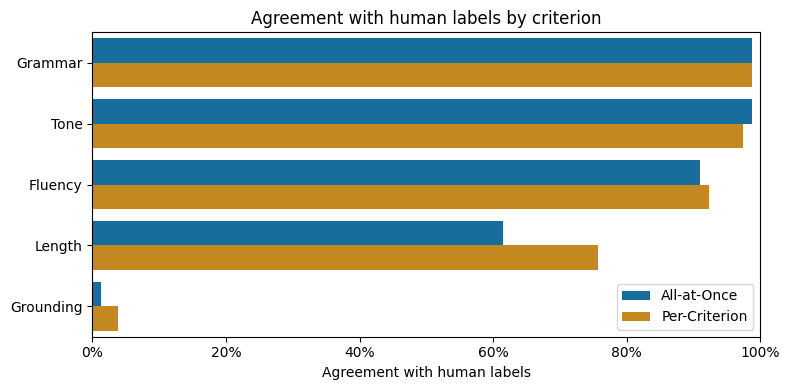

In [ ]:
if agreement_df.empty:
    agreement_output = mo.md(
        "**Agreement chart unavailable until human-labeled rows and both judge outputs are present.**"
    )
else:
    agreement_plot_df = agreement_df[
        [
            "Criterion",
            "All-at-Once (raw)",
            "Per-Criterion (raw)",
        ]
    ].melt(
        id_vars="Criterion",
        var_name="Judge mode",
        value_name="Agreement",
    )
    agreement_plot_df["Judge mode"] = agreement_plot_df["Judge mode"].replace(
        {
            "All-at-Once (raw)": "All-at-Once",
            "Per-Criterion (raw)": "Per-Criterion",
        }
    )

    agreement_fig, agreement_ax = plt.subplots(figsize=(8, 4))
    sns.barplot(
        data=agreement_plot_df,
        x="Agreement",
        y="Criterion",
        hue="Judge mode",
        ax=agreement_ax,
        palette="colorblind",
    )
    agreement_ax.set_xlim(0, 1)
    agreement_ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    agreement_ax.set_xlabel("Agreement with human labels")
    agreement_ax.set_ylabel("")
    agreement_ax.set_title("Agreement with human labels by criterion")
    agreement_ax.legend(title="")
    agreement_fig.tight_layout()
    agreement_output = mo.mpl.interactive(agreement_fig)
agreement_output

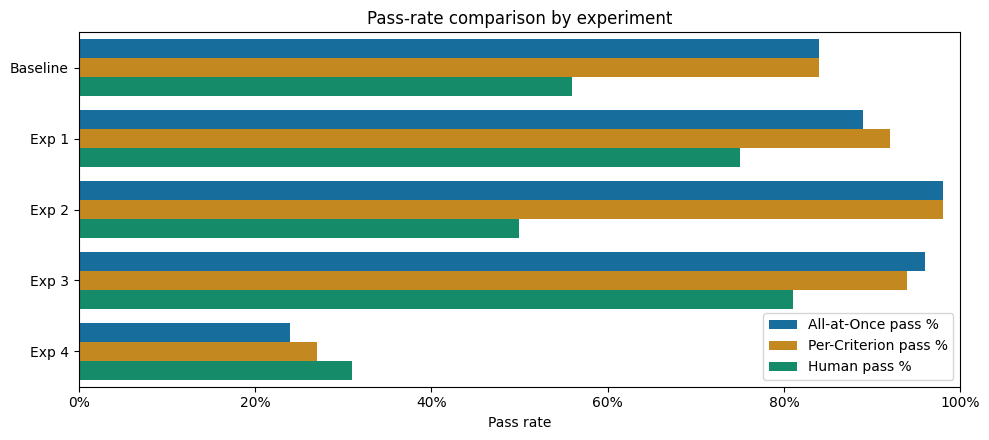

In [ ]:
experiment_plot_df = experiment_summary_df[
    [
        "Experiment",
        "All-at-Once pass %",
        "Per-Criterion pass %",
        "Human pass %",
    ]
].melt(
    id_vars="Experiment",
    var_name="Pass-rate source",
    value_name="Pass rate label",
)
experiment_plot_df["Pass rate"] = (
    pd.to_numeric(
        experiment_plot_df["Pass rate label"].str.rstrip("%"),
        errors="coerce",
    )
    / 100
)
experiment_plot_df = experiment_plot_df.dropna(subset=["Pass rate"])

if experiment_plot_df.empty:
    experiment_output = mo.md(
        "**Pass-rate chart unavailable until Task 6 outputs and human labels are present.**"
    )
else:
    experiment_fig, experiment_ax = plt.subplots(figsize=(10, 4.5))
    sns.barplot(
        data=experiment_plot_df,
        x="Pass rate",
        y="Experiment",
        hue="Pass-rate source",
        ax=experiment_ax,
        palette="colorblind",
    )
    experiment_ax.set_xlim(0, 1)
    experiment_ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    experiment_ax.set_xlabel("Pass rate")
    experiment_ax.set_ylabel("")
    experiment_ax.set_title("Pass-rate comparison by experiment")
    experiment_ax.legend(title="")
    experiment_fig.tight_layout()
    experiment_output = mo.mpl.interactive(experiment_fig)
experiment_output